In [1]:
import sys, os
from pathlib import Path

project_root = str(Path.cwd().parent)

MODEL_DIR = 'models'
LOG_DIR = 'logs'
FILE_NAME = 'mrm.log'
IMG_REF_RAW = os.path.join(project_root, 'x-rays', 'ref2.jpg')
IMG_CUR_RAW = os.path.join(project_root, 'x-rays', 'main2.jpg')


if project_root not in sys.path:
    sys.path.append(project_root)
    print(f'added {project_root} to Python path')

LOG_FILE = os.path.join(project_root, LOG_DIR, FILE_NAME)
LOGGER_NAME = "DRIFT"
CXR_CLIP_RESNET50 = os.path.join(project_root, MODEL_DIR, 'r50_mcc.tar')
CXR_CLIP_SWINTINY = os.path.join(project_root, MODEL_DIR, 'swint_mcc.tar')

added c:\Users\neucl\Dev\Thesis\cxr-diff-vqa to Python path


In [2]:
from lib.config import setup_logging

logger = setup_logging(log_file=LOG_FILE, logger_name=LOGGER_NAME)
logger.info("This log message will correctly go to {LOG_FILE}}")

2025-09-25 16:39:36,552 - DRIFT - INFO - This log message will correctly go to {LOG_FILE}}


In [3]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device_name = torch.cuda.get_device_name(torch.cuda.current_device()) if device == 'cuda' else 'CPU'
logger.info(f'Using device: {device} - {device_name}')

2025-09-25 16:39:39,312 - DRIFT - INFO - Using device: cuda - NVIDIA GeForce RTX 2060


In [4]:
SWIN_TRANSFORMER = "swin_tiny_patch4_window7_224"
RESIDUAL_NEURAL_NETWORK = "resnet50"

BACKBONE_CONFIG = {
    RESIDUAL_NEURAL_NETWORK: {"out_indices": [4]},
    SWIN_TRANSFORMER: {"out_indices": [3]},
}

In [5]:
from torch import nn
import timm


class DirectionalResidualStack(nn.Module):

    def __init__(self, backbone_name="resnet50"):
        super().__init__()

        if backbone_name not in BACKBONE_CONFIG:
            raise ValueError(f"Backbone '{backbone_name}' not supported.")

        config = BACKBONE_CONFIG[backbone_name]

        self.backbone = timm.create_model(
            backbone_name,
            pretrained=True,
            features_only=True,
            out_indices=config["out_indices"],
        )

        # get number of output channels from the backbone
        self.feature_dim = self.backbone.feature_info[-1]["num_chs"]

        logger.info(f"DRS initialized with {backbone_name} ...")
        logger.debug(f"Feature dimension set to: {self.feature_dim}")

    def forward(self, img_ref, img_cur):
        logger.info("[DRS] Entering forward pass...")

        ref_features = self.backbone(img_ref)[0]
        cur_features = self.backbone(img_cur)[0]

        logger.debug(
            f"[DRS] Shape of feature tensor from backbone: {ref_features.shape}"
        )

        r_abs = torch.abs(cur_features - ref_features)

        logger.debug(f"[DRS] Shape of calculated r_abs: {r_abs.shape}")
        logger.info("[DRS] Exiting forward pass.")

        return r_abs


class MaskedResidualModel(nn.Module):
    def __init__(self, drs_model, mask_ratio=0.6):
        super().__init__()
        self.drs = drs_model
        self.mask_ratio = mask_ratio
        self.encoder = nn.Sequential(
            nn.Linear(self.drs.feature_dim, self.drs.feature_dim), nn.GELU()
        )
        self.decoder = nn.Linear(self.drs.feature_dim, self.drs.feature_dim)
        self.mask_token = nn.Parameter(torch.randn(1, 1, self.drs.feature_dim))
        self.loss_fn = nn.MSELoss()

    def forward(self, img_ref, img_cur):

        logger.info("[MRM] Entering forward pass...")

        r_abs = self.drs(img_ref, img_cur)
        logger.debug(f"[MRM] Received r_abs with shape: {r_abs.shape}")

        batch = r_abs.shape[0]
        device = r_abs.device

        # correctly handles both
        # (B, C, H, W) from ResNet
        # and
        # (B, H, W, C) from Swin-T
        if r_abs.dim() == 4:
            # Check if channels are in ResNet format
            logger.info("[MRM] r_abs is 4D. Reshaping to patch format.")

            if r_abs.shape[1] > r_abs.shape[3]:
                r_abs = r_abs.permute(
                    0, 2, 3, 1
                )  # permute (B, C, H, W) -> (B, H, W, C)

            # reshape the unified (B, H, W, C) format to (B, H*W, C)
            patches = r_abs.reshape(batch, -1, self.drs.feature_dim)

            logger.debug(f"[MRM] Reshaped to patches with shape: {patches.shape}")
        else:
            logger.error(f"Unsupported feature map shape: {r_abs.shape}")
            raise ValueError(f"Unsupported feature map shape: {r_abs.shape}")

        logger.debug(
            f"[MRM] Final 'patches' tensor shape before encoder: {patches.shape}"
        )
        logger.debug(
            f"[MRM] Final 'patches' tensor shape before encoder: {patches.shape}"
        )
        logger.debug(
            f"[MRM] Encoder expects input features of size: {self.encoder[0].in_features}"
        )

        # end of correct handling

        num_patches = patches.shape[1]
        rand_indices = torch.rand(batch, num_patches, device=device).argsort(dim=-1)
        num_masked = int(self.mask_ratio * num_patches)
        masked_indices, unmasked_indices = (
            rand_indices[:, :num_masked],
            rand_indices[:, num_masked:],
        )

        batch_range = torch.arange(batch, device=device)[:, None]

        encoded_all_patches = self.encoder(patches)
        encoded_unmasked_patches = encoded_all_patches[batch_range, unmasked_indices]

        full_sequence = self.mask_token.expand(batch, num_patches, -1).clone()
        full_sequence[batch_range, unmasked_indices] = encoded_unmasked_patches

        reconstructed_patches_all = self.decoder(full_sequence)
        reconstructed_masked_patches = reconstructed_patches_all[
            batch_range, masked_indices
        ]
        original_masked_patches = patches[batch_range, masked_indices]

        loss = self.loss_fn(reconstructed_masked_patches, original_masked_patches)
        logger.info("[MRM] Loss calculated successfully")

        return {
            "loss": loss,
            "r_abs": r_abs,
            "patches": patches,
            "reconstructed_patches": reconstructed_patches_all,
            "masked_indices": masked_indices,
            "unmasked_indices": unmasked_indices,
        }

In [6]:
logger.info("--- Testing ResNet50 ---")
try:
    drs_resnet = DirectionalResidualStack(backbone_name=RESIDUAL_NEURAL_NETWORK)
    mrm_resnet = MaskedResidualModel(drs_resnet, mask_ratio=0.6).to(device)
    ref_img_resnet = torch.randn(2, 3, 224, 224).to(device)
    cur_img_resnet = torch.randn(2, 3, 224, 224).to(device)
    mrm_resnet_output = mrm_resnet(ref_img_resnet, cur_img_resnet)
    logger.debug(f"ResNet50 Backbone Feature Dimension: {drs_resnet.feature_dim}")
    logger.debug(f"Reconstruction Loss: {mrm_resnet_output['loss'].item()}")
    logger.success("ResNet50 test PASSED")
except Exception as e:
    logger.error(f"ResNet50 test FAILED Error: {e}")

2025-09-25 16:39:41,914 - DRIFT - INFO - --- Testing ResNet50 ---
2025-09-25 16:39:43,371 - DRIFT - INFO - DRS initialized with resnet50 ...
2025-09-25 16:39:43,373 - DRIFT - DEBUG - Feature dimension set to: 2048
2025-09-25 16:39:43,756 - DRIFT - INFO - [MRM] Entering forward pass...
2025-09-25 16:39:43,757 - DRIFT - INFO - [DRS] Entering forward pass...
2025-09-25 16:39:44,057 - DRIFT - DEBUG - [DRS] Shape of feature tensor from backbone: torch.Size([2, 2048, 7, 7])
2025-09-25 16:39:44,094 - DRIFT - DEBUG - [DRS] Shape of calculated r_abs: torch.Size([2, 2048, 7, 7])
2025-09-25 16:39:44,096 - DRIFT - INFO - [DRS] Exiting forward pass.
2025-09-25 16:39:44,097 - DRIFT - DEBUG - [MRM] Received r_abs with shape: torch.Size([2, 2048, 7, 7])
2025-09-25 16:39:44,098 - DRIFT - INFO - [MRM] r_abs is 4D. Reshaping to patch format.
2025-09-25 16:39:44,100 - DRIFT - DEBUG - [MRM] Reshaped to patches with shape: torch.Size([2, 49, 2048])
2025-09-25 16:39:44,101 - DRIFT - DEBUG - [MRM] Final 'patc

In [7]:
logger.info("--- Testing Swin-T ---")
try:
    drs_swin = DirectionalResidualStack(backbone_name=SWIN_TRANSFORMER)
    mrm_swin = MaskedResidualModel(drs_swin, mask_ratio=0.6).to(device)
    ref_img_swin = torch.randn(2, 3, 224, 224).to(device)
    cur_img_swin = torch.randn(2, 3, 224, 224).to(device)
    mrm_swin_output = mrm_swin(ref_img_swin, cur_img_swin)

    logger.debug(f"SwinTiny Backbone Feature Dimension: {drs_swin.feature_dim}")
    logger.debug(f"Reconstruction Loss: {mrm_swin_output['loss'].item()}")
    logger.success("Swin-T test PASSED")
except Exception as e:
    logger.error(f"Swin-T test FAILED Error: {e}")

2025-09-25 16:39:44,194 - DRIFT - INFO - --- Testing Swin-T ---
2025-09-25 16:39:45,602 - DRIFT - INFO - DRS initialized with swin_tiny_patch4_window7_224 ...
2025-09-25 16:39:45,603 - DRIFT - DEBUG - Feature dimension set to: 768
2025-09-25 16:39:45,703 - DRIFT - INFO - [MRM] Entering forward pass...
2025-09-25 16:39:45,704 - DRIFT - INFO - [DRS] Entering forward pass...
2025-09-25 16:39:45,834 - DRIFT - DEBUG - [DRS] Shape of feature tensor from backbone: torch.Size([2, 7, 7, 768])
2025-09-25 16:39:45,835 - DRIFT - DEBUG - [DRS] Shape of calculated r_abs: torch.Size([2, 7, 7, 768])
2025-09-25 16:39:45,837 - DRIFT - INFO - [DRS] Exiting forward pass.
2025-09-25 16:39:45,838 - DRIFT - DEBUG - [MRM] Received r_abs with shape: torch.Size([2, 7, 7, 768])
2025-09-25 16:39:45,840 - DRIFT - INFO - [MRM] r_abs is 4D. Reshaping to patch format.
2025-09-25 16:39:45,842 - DRIFT - DEBUG - [MRM] Reshaped to patches with shape: torch.Size([2, 49, 768])
2025-09-25 16:39:45,843 - DRIFT - DEBUG - [MRM

In [8]:
from matplotlib import pyplot as plt
from matplotlib import cm
import numpy as np
from torch.nn import functional as F


def plot_difference_heatmap(
    model_output, original_ref_image, original_cur_image, sample_idx=0, backbone_name=""
):
    """
    Creates and plots a human-understandable difference heatmap,
    including the reference and current images.
    """
    # prepare tensors
    with torch.no_grad():
        r_abs = model_output["r_abs"][sample_idx].cpu()
        if r_abs.shape[0] > r_abs.shape[2]:
            r_abs = r_abs.permute(1, 2, 0)
        heatmap_2d = r_abs.mean(dim=-1)
        heatmap_to_upsample = heatmap_2d.unsqueeze(0).unsqueeze(0)
        upsampled_heatmap = (
            F.interpolate(
                heatmap_to_upsample,
                size=(224, 224),
                mode="bilinear",
                align_corners=False,
            )
            .squeeze()
            .numpy()
        )
        upsampled_heatmap = (upsampled_heatmap - upsampled_heatmap.min()) / (
            upsampled_heatmap.max() - upsampled_heatmap.min()
        )

    # prepare images for Plotting
    colored_heatmap = cm.coolwarm(upsampled_heatmap)[:, :, :3]
    ref_np = np.array(original_ref_image.resize((224, 224))) / 255.0
    cur_np = np.array(original_cur_image.resize((224, 224))) / 255.0
    alpha = 0.5
    blended_image = (1 - alpha) * cur_np + alpha * colored_heatmap

    # plotting
    # change subplot layout to 1 row, 4 columns
    fig, axs = plt.subplots(1, 4, figsize=(24, 6))
    fig.suptitle(f"Human-Understandable Difference Map using {backbone_name}", fontsize=20)

    # column 1: reference image
    axs[0].imshow(ref_np)
    axs[0].set_title("Reference Image (Past)", fontsize=14)
    axs[0].axis("off")

    # column 2: current image
    axs[1].imshow(cur_np)
    axs[1].set_title("Current Image", fontsize=14)
    axs[1].axis("off")

    # column 3: upsampled heatmap
    axs[2].imshow(upsampled_heatmap, cmap="coolwarm")
    axs[2].set_title("Difference Heatmap", fontsize=14)
    axs[2].axis("off")

    # column 4: blended difference map
    axs[3].imshow(blended_image)
    axs[3].set_title("Blended Difference Map", fontsize=14)
    axs[3].axis("off")
    plt.show()


def plot_mrm_results(model_output, sample_idx=0, backbone_name=""):

    with torch.no_grad():
        patches = model_output["patches"][sample_idx].cpu()
        reconstructed = model_output["reconstructed_patches"][sample_idx].cpu()
        masked_indices = model_output["masked_indices"][sample_idx].cpu()
        unmasked_indices = model_output["unmasked_indices"][sample_idx].cpu()

        # determine the original grid size (e.g., 7x7)
        num_patches = patches.shape[0]

        height = width = int(num_patches**0.5)
        channels = patches.shape[1]

        # original difference image
        # reshape patches to an image and take the mean across channels for a grayscale view
        original_img = patches.reshape(height, width, channels).mean(dim=-1)

        # masked input image
        # create a copy and set the masked parts to a neutral value (gray)
        masked_patches_viz = patches.clone()

        masked_patches_viz[masked_indices] = torch.mean(patches)
        masked_img = masked_patches_viz.reshape(height, width, channels).mean(dim=-1)

        # reconstructed output image
        # create a canvas and fill it with the original unmasked patches
        # and the newly reconstructed masked patches.
        reconstructed_viz = torch.zeros_like(patches)

        reconstructed_viz[unmasked_indices] = patches[unmasked_indices]
        reconstructed_viz[masked_indices] = reconstructed[masked_indices]
        reconstructed_img = reconstructed_viz.reshape(height, width, channels).mean(
            dim=-1
        )

    fig, axs = plt.subplots(1, 3, figsize=(18, 6))

    title = f"MRM Visualization for {backbone_name}"
    fig.suptitle(title, fontsize=20)

    axs[0].imshow(original_img, cmap="plasma")
    axs[0].set_title("Original Difference Map", fontsize=14)
    axs[0].axis("off")

    axs[1].imshow(masked_img, cmap="plasma")
    axs[1].set_title("Masked Input", fontsize=14)
    axs[1].axis("off")

    axs[2].imshow(reconstructed_img, cmap="plasma")
    axs[2].set_title("Reconstructed Output", fontsize=14)
    axs[2].axis("off")

    plt.show()

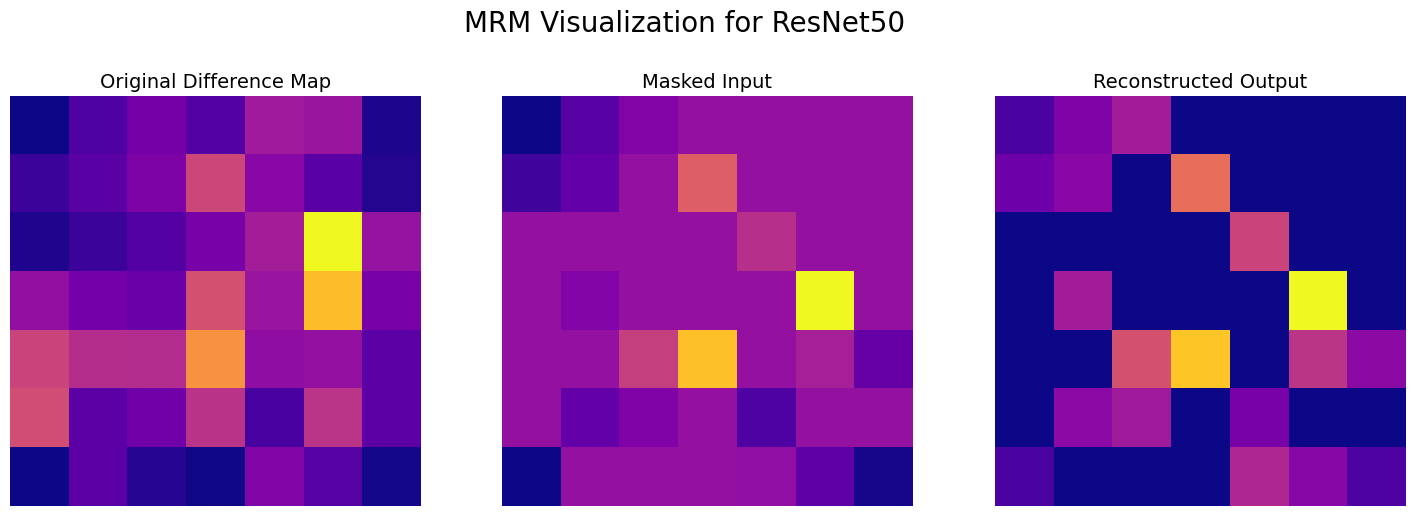

In [9]:
plot_mrm_results(mrm_resnet_output, sample_idx=0, backbone_name='ResNet50')

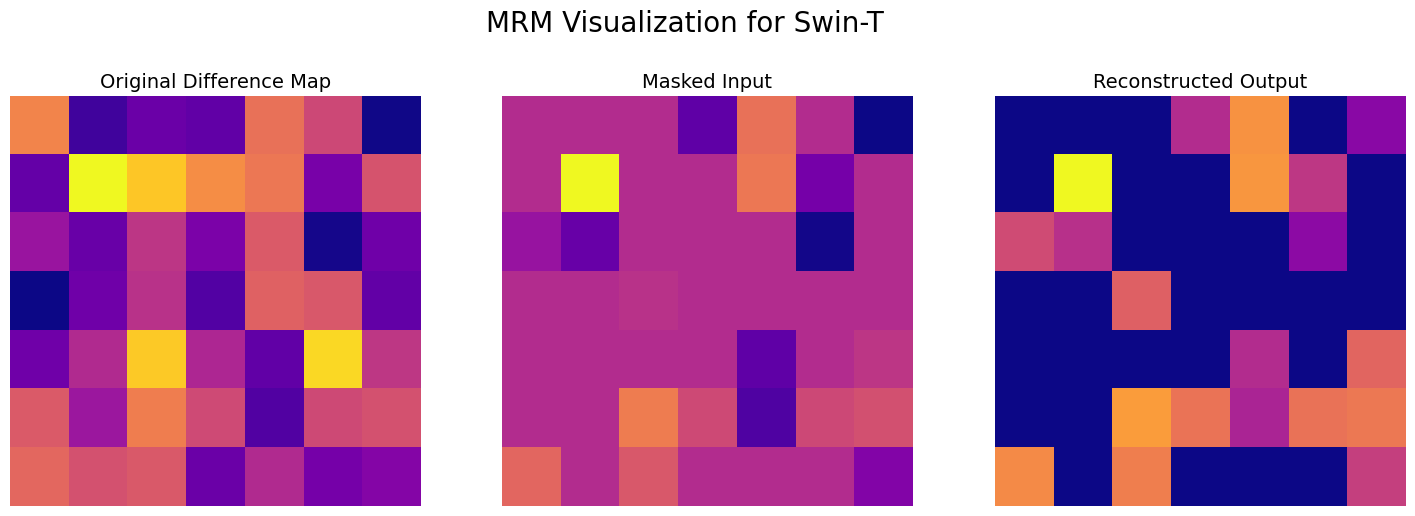

In [10]:
plot_mrm_results(mrm_swin_output, sample_idx=0, backbone_name='Swin-T')

In [11]:
from torchvision import transforms
from PIL import Image

image_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(  # normalize tensor pixel values
            mean=[0.485, 0.456, 0.406],  # standard ImageNet mean
            std=[0.229, 0.224, 0.225],  # standard ImageNet std
        ),
    ]
)

viz_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

img_ref_raw = Image.open(IMG_REF_RAW).convert('RGB')
img_cur_raw = Image.open(IMG_CUR_RAW).convert('RGB')

img_ref_tensor = image_transform(img_ref_raw)
img_cur_tensor = image_transform(img_cur_raw)

batch_ref = img_ref_tensor.unsqueeze(0).to(device)
batch_cur = img_cur_tensor.unsqueeze(0).to(device)


In [12]:
drs_resnet50 = DirectionalResidualStack(backbone_name=RESIDUAL_NEURAL_NETWORK)

try:
    downloaded_weights = torch.load(CXR_CLIP_RESNET50, map_location=device)
    drs_resnet50.load_state_dict(downloaded_weights, strict=False)

    logger.info(f"Successfully loaded custom weights from: {CXR_CLIP_RESNET50}")
    mrm_resnet50 = MaskedResidualModel(drs_resnet50).to(device)
    mrm_resnet50.eval()

    # img_ref_raw = Image.open(IMG_REF_RAW).convert('RGB')
    # img_cur_raw = Image.open(IMG_CUR_RAW).convert('RGB')

    # img_ref_tensor = image_transform(img_ref_raw)
    # img_cur_tensor = image_transform(img_cur_raw)

    # batch_ref = img_ref_tensor.unsqueeze(0).to(device)
    # batch_cur = img_cur_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        mrm_resnet50_output = mrm_resnet50(batch_ref, batch_cur)

    logger.info("Successfully processed real images!")
    logger.debug(f'calculated loss: {mrm_resnet50_output["loss"].item()}')

except FileNotFoundError as e:
    logger.error(f'check your model path: {CXR_CLIP_RESNET50}')
    logger.critical(f"model not found: {e}")
    raise e

2025-09-25 16:39:48,036 - DRIFT - INFO - DRS initialized with resnet50 ...
2025-09-25 16:39:48,038 - DRIFT - DEBUG - Feature dimension set to: 2048
2025-09-25 16:39:49,490 - DRIFT - INFO - Successfully loaded custom weights from: c:\Users\neucl\Dev\Thesis\cxr-diff-vqa\models\r50_mcc.tar
2025-09-25 16:39:49,612 - DRIFT - INFO - [MRM] Entering forward pass...
2025-09-25 16:39:49,613 - DRIFT - INFO - [DRS] Entering forward pass...
2025-09-25 16:39:49,665 - DRIFT - DEBUG - [DRS] Shape of feature tensor from backbone: torch.Size([1, 2048, 7, 7])
2025-09-25 16:39:49,667 - DRIFT - DEBUG - [DRS] Shape of calculated r_abs: torch.Size([1, 2048, 7, 7])
2025-09-25 16:39:49,668 - DRIFT - INFO - [DRS] Exiting forward pass.
2025-09-25 16:39:49,669 - DRIFT - DEBUG - [MRM] Received r_abs with shape: torch.Size([1, 2048, 7, 7])
2025-09-25 16:39:49,670 - DRIFT - INFO - [MRM] r_abs is 4D. Reshaping to patch format.
2025-09-25 16:39:49,671 - DRIFT - DEBUG - [MRM] Reshaped to patches with shape: torch.Size(

In [13]:
drs_swintiny = DirectionalResidualStack(backbone_name=SWIN_TRANSFORMER)
try:
    downloaded_weights = torch.load(CXR_CLIP_SWINTINY, map_location=device)
    drs_swintiny.load_state_dict(downloaded_weights, strict=False)

    logger.info(f"Successfully loaded custom weights from: {CXR_CLIP_SWINTINY}")
    mrm_swintiny = MaskedResidualModel(drs_swintiny).to(device)
    mrm_swintiny.eval()

    with torch.no_grad():
        mrm_swintiny_output = mrm_swintiny(batch_ref, batch_cur)

    logger.info("Successfully processed real images!")
    logger.debug(f'calculated loss: {mrm_swintiny_output["loss"].item()}')

except FileNotFoundError as e:
    logger.error(f'check your model path: {CXR_CLIP_SWINTINY}')
    logger.critical(f"model not found: {e}")
    raise e

2025-09-25 16:39:51,031 - DRIFT - INFO - DRS initialized with swin_tiny_patch4_window7_224 ...
2025-09-25 16:39:51,033 - DRIFT - DEBUG - Feature dimension set to: 768
2025-09-25 16:39:53,970 - DRIFT - INFO - Successfully loaded custom weights from: c:\Users\neucl\Dev\Thesis\cxr-diff-vqa\models\swint_mcc.tar
2025-09-25 16:39:54,047 - DRIFT - INFO - [MRM] Entering forward pass...
2025-09-25 16:39:54,048 - DRIFT - INFO - [DRS] Entering forward pass...
2025-09-25 16:39:54,085 - DRIFT - DEBUG - [DRS] Shape of feature tensor from backbone: torch.Size([1, 7, 7, 768])
2025-09-25 16:39:54,086 - DRIFT - DEBUG - [DRS] Shape of calculated r_abs: torch.Size([1, 7, 7, 768])
2025-09-25 16:39:54,087 - DRIFT - INFO - [DRS] Exiting forward pass.
2025-09-25 16:39:54,089 - DRIFT - DEBUG - [MRM] Received r_abs with shape: torch.Size([1, 7, 7, 768])
2025-09-25 16:39:54,091 - DRIFT - INFO - [MRM] r_abs is 4D. Reshaping to patch format.
2025-09-25 16:39:54,093 - DRIFT - DEBUG - [MRM] Reshaped to patches with 

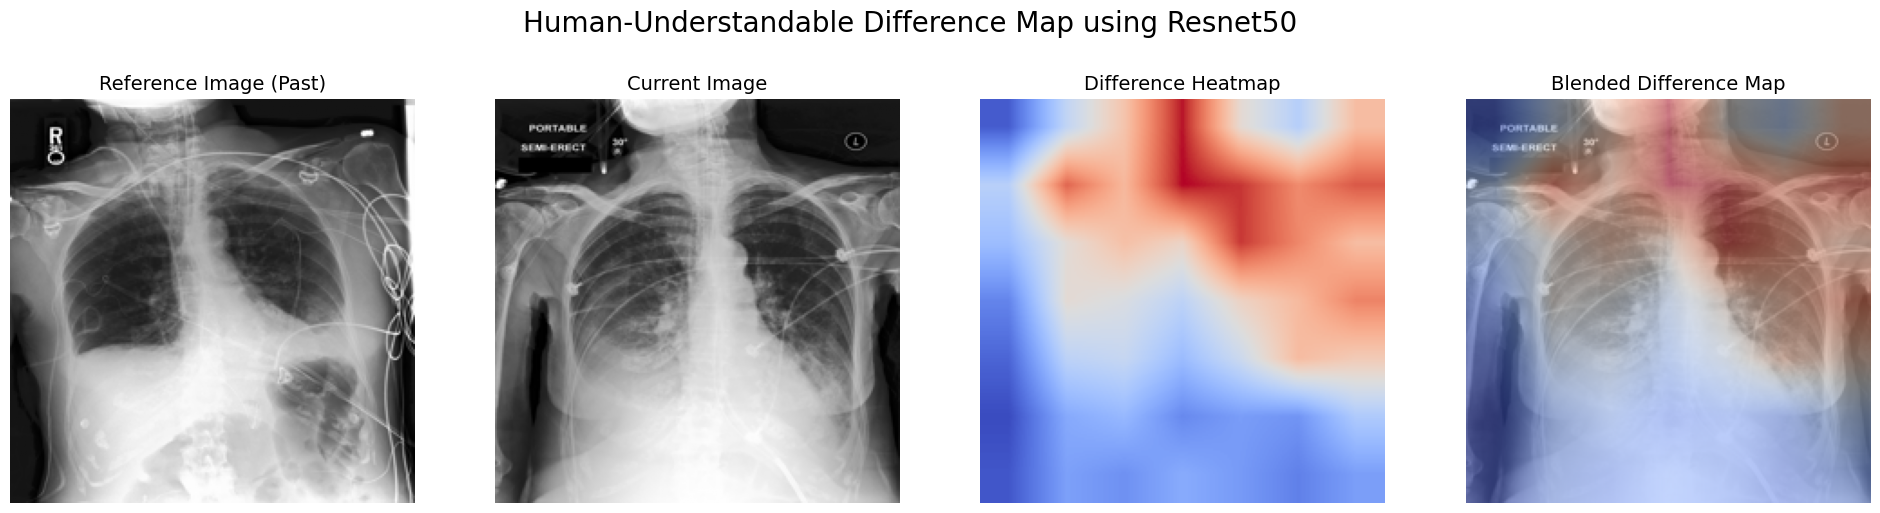

In [14]:
plot_difference_heatmap(
    mrm_resnet50_output,
    original_ref_image=img_ref_raw,
    original_cur_image=img_cur_raw,
    sample_idx=0,
    backbone_name='Resnet50'
)

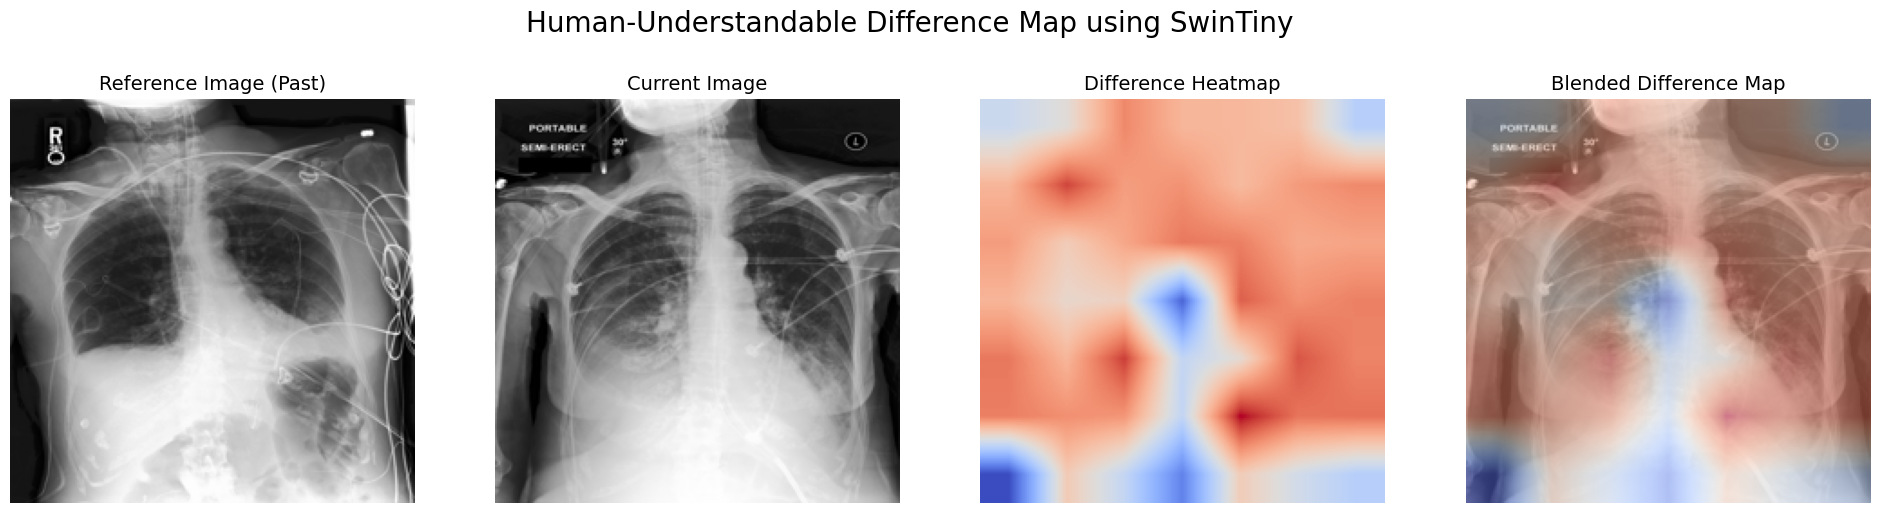

In [15]:
plot_difference_heatmap(
    mrm_swintiny_output,
    original_ref_image=img_ref_raw,
    original_cur_image=img_cur_raw,
    sample_idx=0,
    backbone_name='SwinTiny'
)